In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

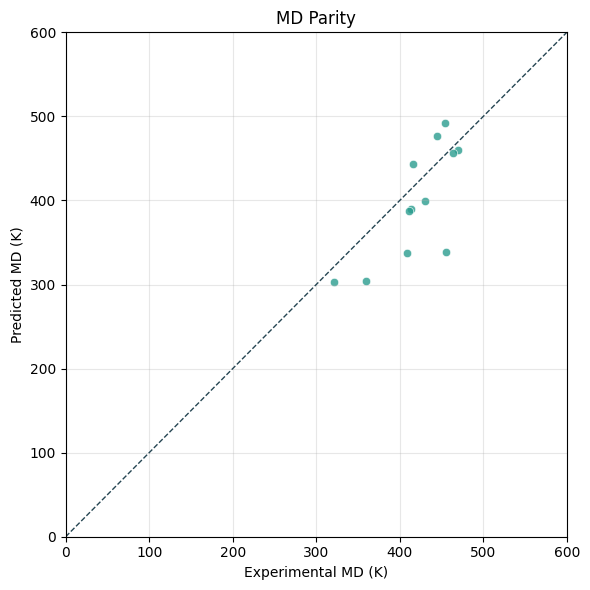

In [4]:
# 读数据并清洗
df = pd.read_csv("../data/raw/output2.csv").rename(columns={"MD/K": "md_k"}).dropna(subset=["pred", "md_k"])
true = df["md_k"].to_numpy()
pred = df["pred"].to_numpy()
res = pred - true

# 指标
mae = np.mean(np.abs(res))
rmse = np.sqrt(np.mean(res**2))
r2 = 1 - np.sum(res**2) / np.sum((true - true.mean())**2)

out_dir = Path("pred_graphs"); out_dir.mkdir(exist_ok=True)

# Parity 图
lim_min, lim_max = min(true.min(), pred.min()), max(true.max(), pred.max())
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true, pred, color="#2a9d8f", alpha=0.8, edgecolor="white", linewidth=0.5)
ax.plot([0, 600], [0, 600], "--", color="#264653", linewidth=1)
ax.set(xlabel="Experimental MD (K)", ylabel="Predicted MD (K)",
       title=f"MD Parity",
       xlim=(0, 600), ylim=(0, 600))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "md_parity.png", dpi=300)
plt.show()



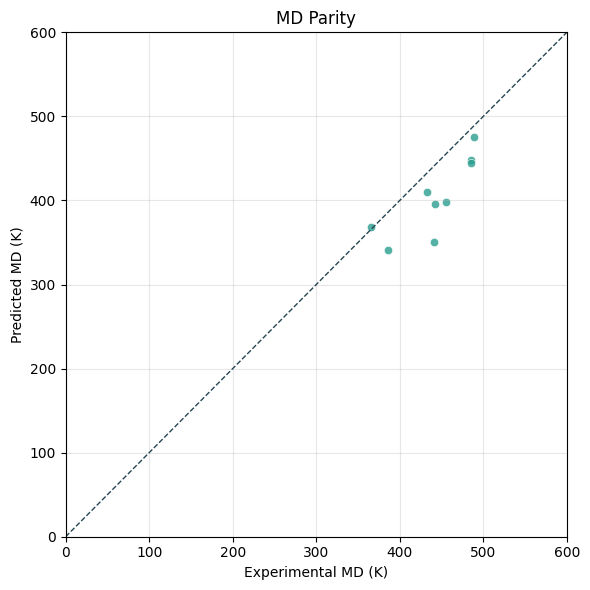

In [5]:
# 读数据并清洗
df = pd.read_csv("../data/raw/MD_pred.csv").rename(columns={"MD/K": "md_k"}).dropna(subset=["pred", "md_k"])
true = df["md_k"].to_numpy()
pred = df["pred_old"].to_numpy()
res = pred - true

# 指标
mae = np.mean(np.abs(res))
rmse = np.sqrt(np.mean(res**2))
r2 = 1 - np.sum(res**2) / np.sum((true - true.mean())**2)

out_dir = Path("pred_graphs"); out_dir.mkdir(exist_ok=True)

# Parity 图
lim_min, lim_max = min(true.min(), pred.min()), max(true.max(), pred.max())
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true, pred, color="#2a9d8f", alpha=0.8, edgecolor="white", linewidth=0.5)
ax.plot([0, 600], [0, 600], "--", color="#264653", linewidth=1)
ax.set(xlabel="Experimental MD (K)", ylabel="Predicted MD (K)",
       title=f"MD Parity",
       xlim=(0, 600), ylim=(0, 600))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "md_parity.png", dpi=300)
plt.show()


# kaggle数据集预测结果

R² : 0.5354595933992363
MAE: 56.61452276505579
RMSE: 75.73586741756986


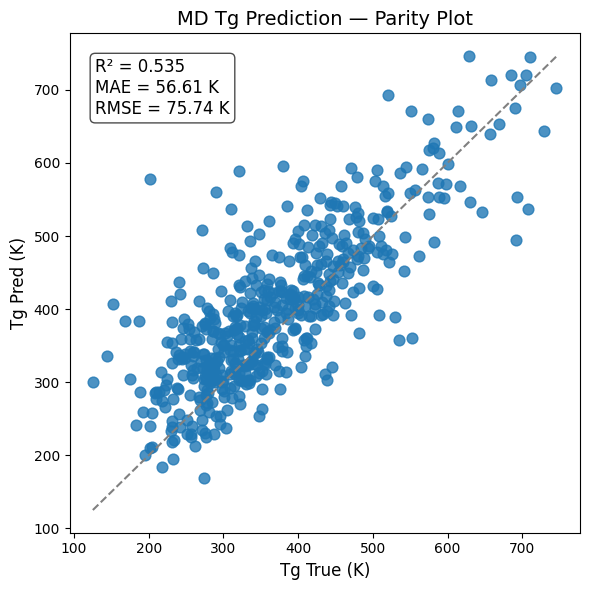

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ===========================
# 1. 读取数据
# ===========================
df = pd.read_csv("../data/raw/kaggle_pred.csv")   # 必须包含列：Tg, pred

y_true = df["Tg"].values
y_pred = df["pred"].values

# ===========================
# 2. 计算误差指标
# ===========================
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print("R² :", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# ===========================
# 3. 绘制真实值 VS 预测值散点图
# ===========================
plt.figure(figsize=(6, 6))

plt.scatter(y_true, y_pred, s=60, alpha=0.8)

# 45° 理想线
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "--", color="gray")

plt.xlabel("Tg True (K)", fontsize=12)
plt.ylabel("Tg Pred (K)", fontsize=12)
plt.title("MD Tg Prediction — Parity Plot", fontsize=14)

# 在图内写误差指标
plt.text(
    0.05, 0.95,
    f"R² = {r2:.3f}\nMAE = {mae:.2f} K\nRMSE = {rmse:.2f} K",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.tight_layout()
plt.show()


# 实验数据集

R² : 0.2576188844098434
MAE: 101.0053112986731
RMSE: 138.28890454038486


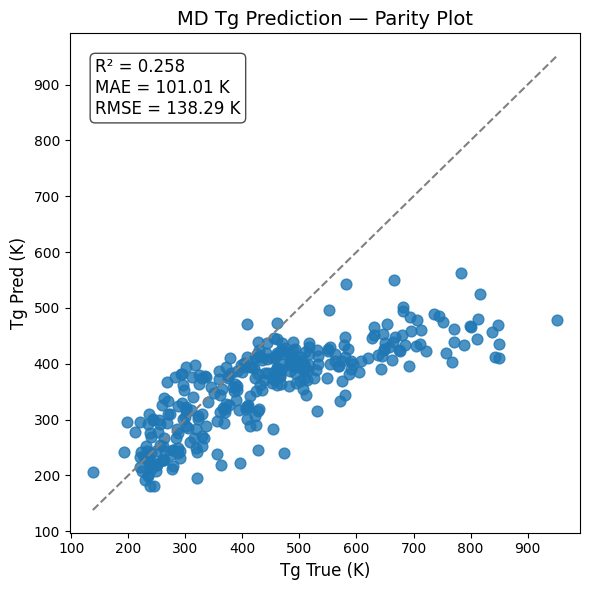

In [7]:
df = pd.read_csv("../data/raw/MDsci_pred.csv")   # 必须包含列：Tg, pred

y_true = df["Tg"].values
y_pred = df["pred"].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print("R² :", r2)
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(6, 6))

plt.scatter(y_true, y_pred, s=60, alpha=0.8)

# 45° 理想线
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "--", color="gray")

plt.xlabel("Tg True (K)", fontsize=12)
plt.ylabel("Tg Pred (K)", fontsize=12)
plt.title("MD Tg Prediction — Parity Plot", fontsize=14)

# 在图内写误差指标
plt.text(
    0.05, 0.95,
    f"R² = {r2:.3f}\nMAE = {mae:.2f} K\nRMSE = {rmse:.2f} K",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.tight_layout()
plt.show()


# 实验数据集

R² : 0.6541700687659093
MAE: 52.269818308996776
RMSE: 69.92749260152385


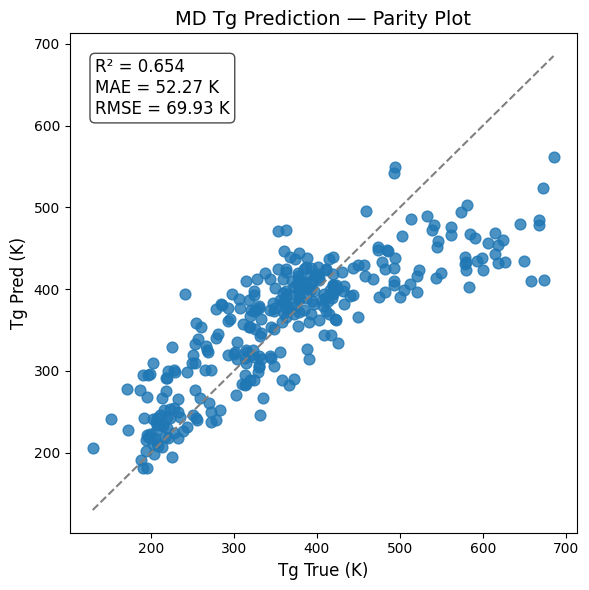

In [8]:
df = pd.read_csv("../data/raw/Expsci_pred.csv")   # 必须包含列：Tg, pred

y_true = df["Tg"].values
y_pred = df["pred"].values

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print("R² :", r2)
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(6, 6))

plt.scatter(y_true, y_pred, s=60, alpha=0.8)

# 45° 理想线
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "--", color="gray")

plt.xlabel("Tg True (K)", fontsize=12)
plt.ylabel("Tg Pred (K)", fontsize=12)
plt.title("MD Tg Prediction — Parity Plot", fontsize=14)

# 在图内写误差指标
plt.text(
    0.05, 0.95,
    f"R² = {r2:.3f}\nMAE = {mae:.2f} K\nRMSE = {rmse:.2f} K",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.tight_layout()
plt.show()


In [ ]:
# 绘制密度随温度变化的曲线

# 尝试读取常见命名的数据文件（需包含列：T 或 Temperature；rho 或 density）
candidate_paths = [
    "data/raw/Tg_density_T.csv"
]

data = None
for p in candidate_paths:
    try:
        tmp = pd.read_csv(p)
        data = tmp
        data_path = p
        break
    except Exception:
        continue

if data is None:
    raise FileNotFoundError(
        "未找到密度-温度数据文件，请提供包含列[T/Temperature, rho/density]的CSV，"
        "例如 ../data/raw/density_temp.csv"
    )

# 统一列名
cols = {c.lower(): c for c in data.columns}
T_col = cols.get("t") or cols.get("temperature")
rho_col = cols.get("rho") or cols.get("density")

if T_col is None or rho_col is None:
    raise ValueError("CSV需包含温度列[T或Temperature]与密度列[rho或density]")

T = data[T_col].to_numpy()
rho = data[rho_col].to_numpy()

# 排序（按温度）
order = np.argsort(T)
T = T[order]
rho = rho[order]

plt.figure(figsize=(7, 5))
plt.plot(T, rho, color="#2a9d8f", linewidth=2)
plt.scatter(T, rho, color="#2a9d8f", s=20, alpha=0.8)

plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Density (g/cm³)", fontsize=12)
plt.title("Density vs. Temperature", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

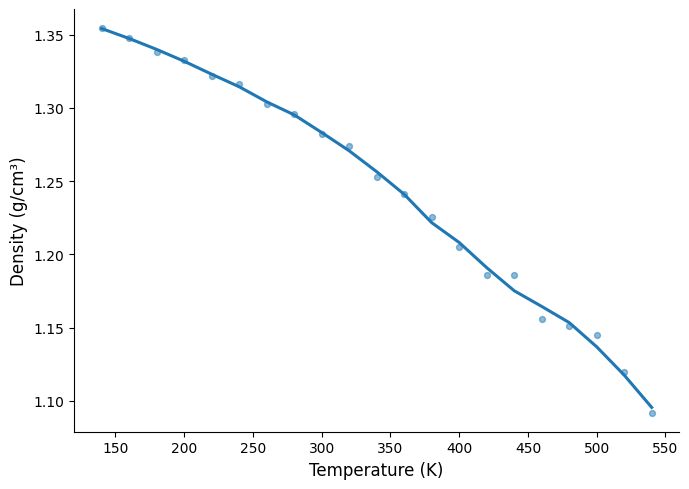

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

data = pd.read_csv("../data/raw/Tg_density_T.csv")

# 统一列名
cols = {c.lower(): c for c in data.columns}
T_col = cols.get("t") or cols.get("temperature")
rho_col = cols.get("rho") or cols.get("density")

if T_col is None or rho_col is None:
    raise ValueError("CSV需包含温度列[T或Temperature]与密度列[rho或density]")

T = data[T_col].to_numpy()
rho = data[rho_col].to_numpy()

# 按温度排序
order = np.argsort(T)
T = T[order]
rho = rho[order]

# 平滑处理（保留物理趋势）
rho_smooth = savgol_filter(rho, window_length=7, polyorder=2)

plt.figure(figsize=(7, 5))

# 原始数据（淡色点）
plt.scatter(T, rho, s=18, alpha=0.5)

# 平滑曲线（主曲线）
plt.plot(T, rho_smooth, linewidth=2.2)

plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Density (g/cm³)", fontsize=12)
plt.title("", fontsize=14)

# 关闭网格，科研图更干净
plt.grid(False)

# 去掉上、右边框（可选，但非常像论文）
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


python demo/shap_gnn.py \
  --ckpt_path checkpoints/best_rmse_35.089K_ep032.pt \
  --manifest data/graphs_tg2/manifest.csv \
  --root data/graphs_tg2 \
  --polybert_path polybert \
  --out_dir outputs_shap \
  --background 8 --samples 16 --feature_idx 0


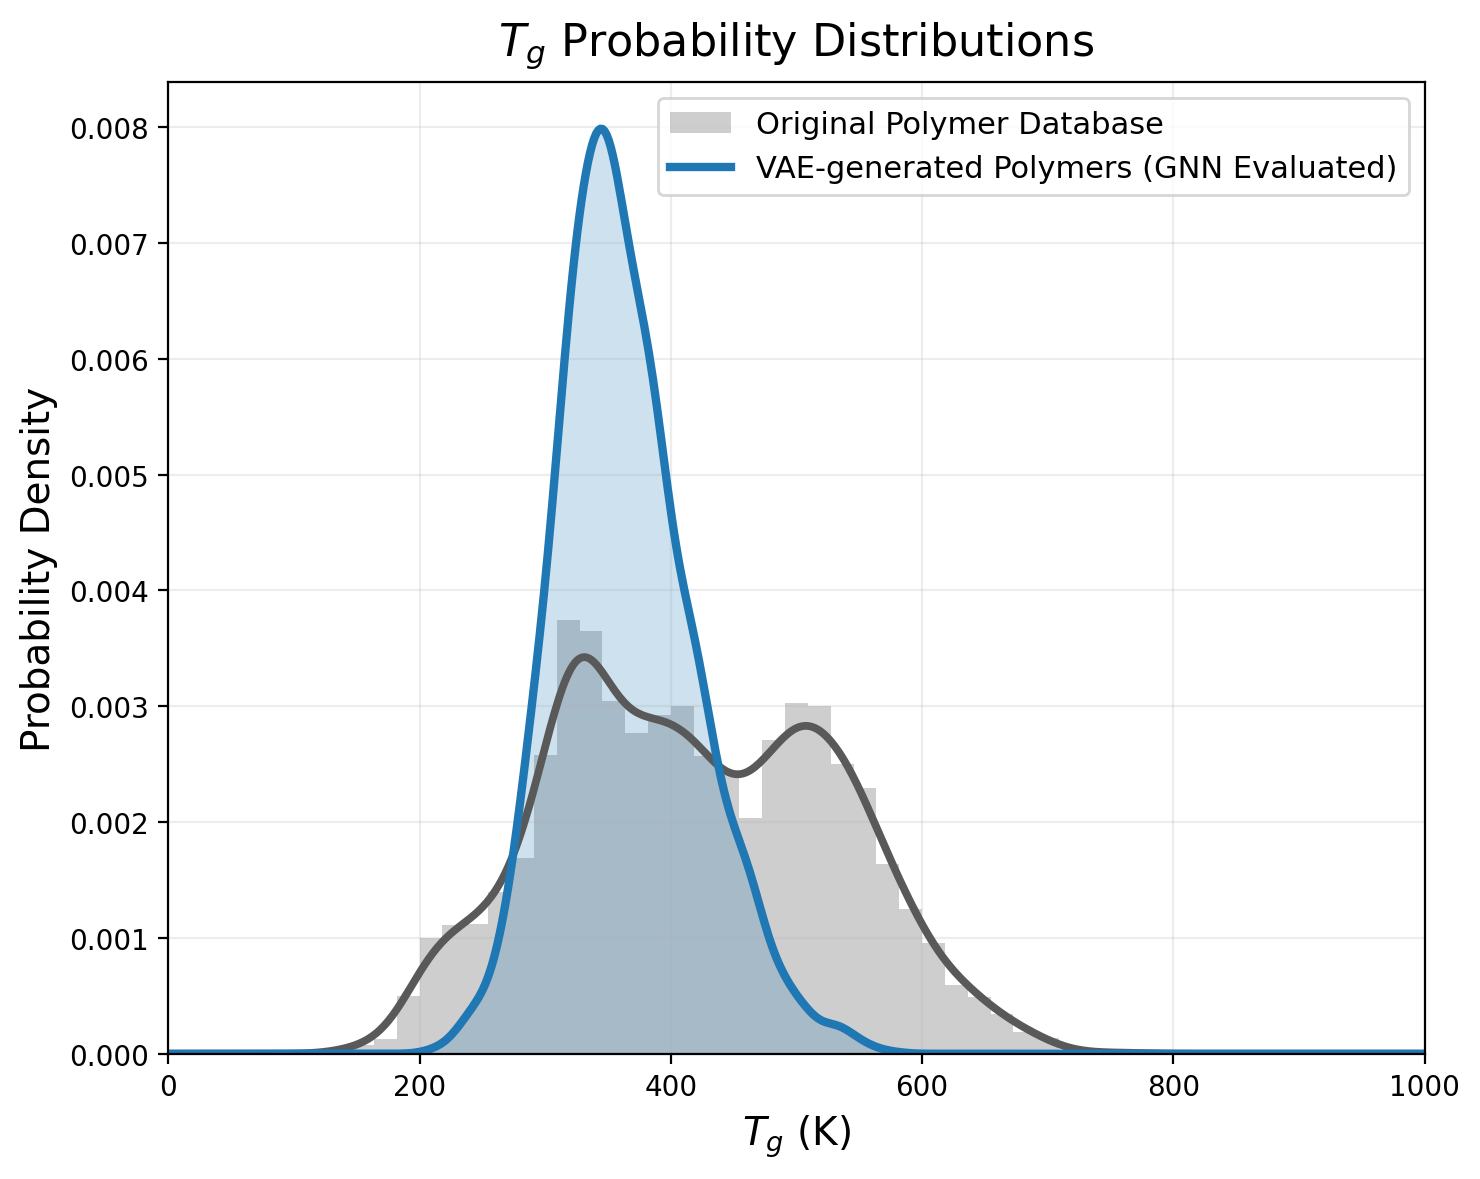

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# KDE 用 scipy（最稳妥）
from scipy.stats import gaussian_kde


def freedman_diaconis_bins(x, xlim=None):
    """用 Freedman–Diaconis 规则自动给 bins（更“像论文”一点）"""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 10

    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr == 0:
        return 20

    bin_width = 2 * iqr * (x.size ** (-1/3))
    if bin_width <= 0:
        return 20

    if xlim is None:
        xmin, xmax = x.min(), x.max()
    else:
        xmin, xmax = xlim

    return max(10, int(np.ceil((xmax - xmin) / bin_width)))


def plot_tg_distributions(
    file_a, col_a,
    file_b, col_b,
    label_a="Original Polymer Database",
    label_b="VAE-generated Polymers (GNN Evaluated)",
    bw_method="scott",          # KDE 带宽：'scott'/'silverman'/float
    xlim=None,                  # 例如 (-50, 350)
    sample_b_for_kde=200000,    # B 很大时，抽样做 KDE（速度更快）
    dpi=200
):
    # --- 读取数据 ---
    a = pd.read_csv(file_a)[col_a].dropna().astype(float).to_numpy()
    b = pd.read_csv(file_b)[col_b].dropna().astype(float).to_numpy()

    # 可选：B 太大就抽样（KDE O(N)~O(N*grid) 可能慢）
    if b.size > sample_b_for_kde:
        rng = np.random.default_rng(0)
        b_kde = rng.choice(b, size=sample_b_for_kde, replace=False)
    else:
        b_kde = b

    # --- x 轴范围 ---
    if xlim is None:
        xmin = np.min([a.min(), b.min()]) - 10
        xmax = np.max([a.max(), b.max()]) + 10
        xlim = (xmin, xmax)

    x = np.linspace(xlim[0], xlim[1], 600)

    # --- KDE ---
    kde_a = gaussian_kde(a, bw_method=bw_method)
    kde_b = gaussian_kde(b_kde, bw_method=bw_method)

    ya = kde_a(x)
    yb = kde_b(x)

    # --- bins（给 A 的直方图） ---
    bins = freedman_diaconis_bins(a, xlim=xlim)

    # --- 画图 ---
    fig, ax = plt.subplots(figsize=(7.5, 6), dpi=dpi)

    # A：直方图（灰色）
    ax.hist(
        a, bins=bins, range=xlim, density=True,
        color="0.65", alpha=0.55, edgecolor="none",
        label=label_a
    )

    # A：KDE 灰线
    ax.plot(x, ya, color="0.35", lw=2.8)

    # B：KDE 蓝线 + 填充
    ax.plot(x, yb, color="tab:blue", lw=3.0, label=label_b)
    ax.fill_between(x, 0, yb, color="tab:blue", alpha=0.22)

    # --- 美化 ---
    ax.set_xlim(*xlim)
    ax.set_xlabel(r"$T_g$ (K)", fontsize=14)
    ax.set_ylabel("Probability Density", fontsize=14)
    ax.set_title(r"$T_g$ Probability Distributions", fontsize=16, pad=10)

    ax.grid(True, alpha=0.22)
    ax.legend(frameon=True, fontsize=11)
    plt.tight_layout()
    plt.show()


# ====== 你只需要改这里 ======
plot_tg_distributions(
    file_a="../data/raw/PSMILES_Tg_only.csv", col_a="Tg",
    file_b="../data/raw/samples_tg_predictions2.csv", col_b="pred",
    xlim=(0, 1000),        # 跟你截图类似
    bw_method="scott"
)
